In [1]:
!pip install folium

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

In [4]:
df = pd.read_csv("real_estate_data.csv")

df.head()

,Property_ID,Location,Area_sqft,Bedrooms,Bathrooms,Age,Parking,Furnished,Property_Type,Price
0,1,Chennai,900,3,3,1,No,No,Apartment,8300000
1,2,Bangalore,917,2,2,2,Yes,Semi,Villa,8126500
2,3,Hyderabad,934,3,3,3,Yes,Yes,Independent House,8453000
3,4,Coimbatore,951,3,3,4,No,No,Apartment,8529500
4,5,Madurai,968,2,2,5,Yes,Semi,Villa,8356000


In [5]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    100 non-null    int64 
 1   Location       100 non-null    object
 2   Area_sqft      100 non-null    int64 
 3   Bedrooms       100 non-null    int64 
 4   Bathrooms      100 non-null    int64 
 5   Age            100 non-null    int64 
 6   Parking        100 non-null    object
 7   Furnished      100 non-null    object
 8   Property_Type  100 non-null    object
 9   Price          100 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 7.9+ KB
None

Missing Values:
Property_ID      0
Location         0
Area_sqft        0
Bedrooms         0
Bathrooms        0
Age              0
Parking          0
Furnished        0
Property_Type    0
Price            0
dtype: int64

Statistics:
       Property_ID    Area_sqft    Bedrooms   Bathrooms         Age  \
count   100.000000   

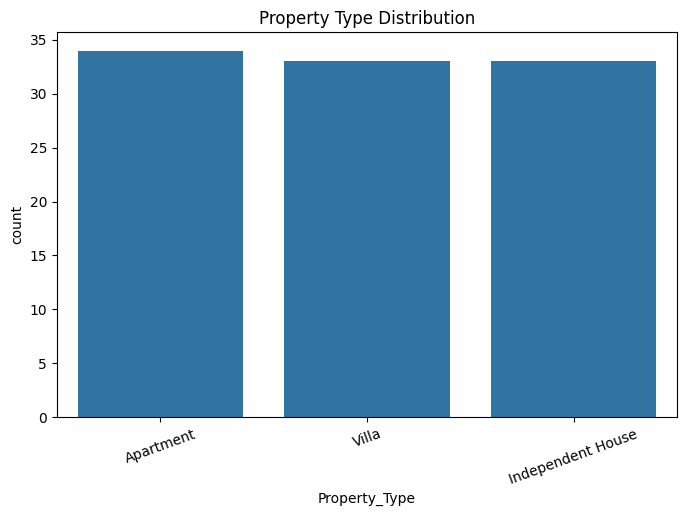

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Property_Type")

plt.title("Property Type Distribution")

plt.xticks(rotation=20)

plt.show()

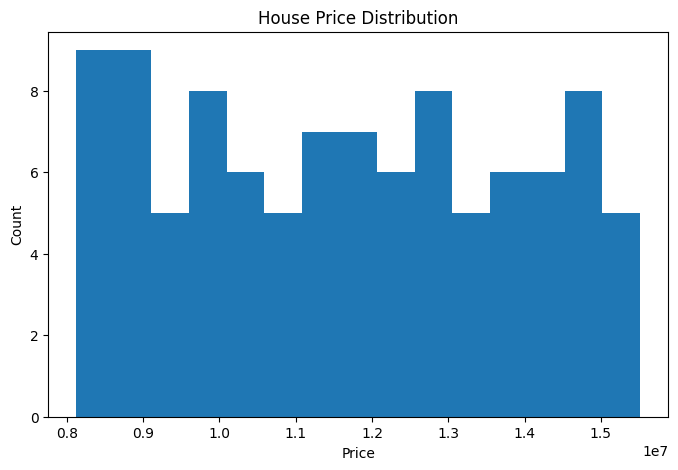

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"],bins=15)

plt.title("House Price Distribution")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

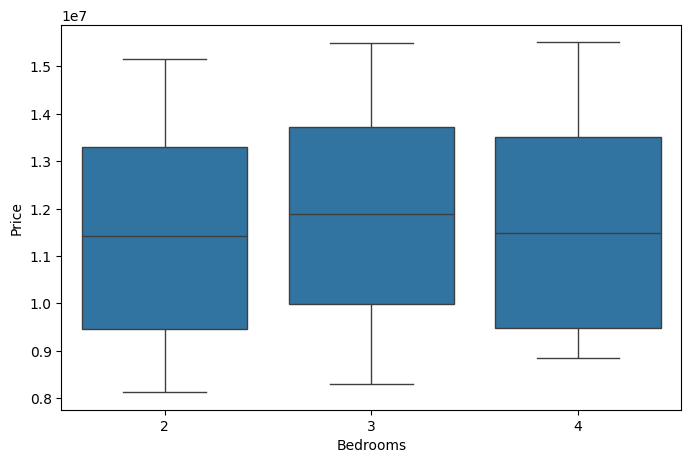

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Bedrooms",y="Price",data=df)

plt.show()

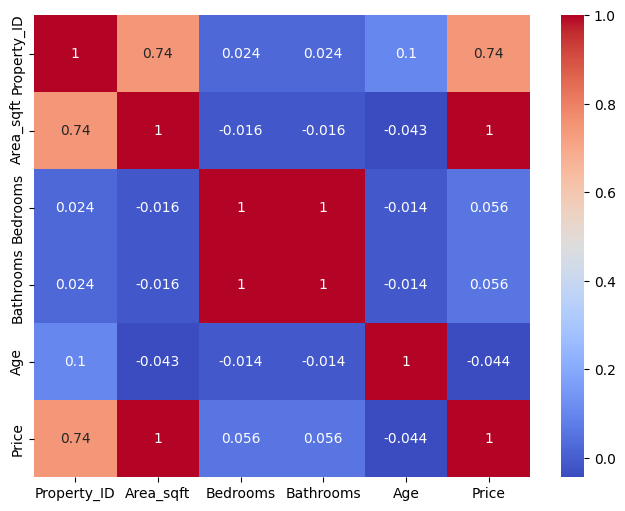

In [9]:
numeric = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm")

plt.show()

In [10]:
location_coordinates = {
    "Chennai":[13.0827,80.2707],
    "Bangalore":[12.9716,77.5946],
    "Hyderabad":[17.3850,78.4867],
    "Coimbatore":[11.0168,76.9558],
    "Madurai":[9.9252,78.1198]
}

df["Latitude"] = df["Location"].apply(lambda x: location_coordinates[x][0])
df["Longitude"] = df["Location"].apply(lambda x: location_coordinates[x][1])

df.head()

,Property_ID,Location,Area_sqft,Bedrooms,Bathrooms,Age,Parking,Furnished,Property_Type,Price,Latitude,Longitude
0,1,Chennai,900,3,3,1,No,No,Apartment,8300000,13.0827,80.2707
1,2,Bangalore,917,2,2,2,Yes,Semi,Villa,8126500,12.9716,77.5946
2,3,Hyderabad,934,3,3,3,Yes,Yes,Independent House,8453000,17.3850,78.4867
3,4,Coimbatore,951,3,3,4,No,No,Apartment,8529500,11.0168,76.9558
4,5,Madurai,968,2,2,5,Yes,Semi,Villa,8356000,9.9252,78.1198


In [11]:
india_map = folium.Map(
    location=[12.97,78.65],
    zoom_start=6
)

for i,row in df.iterrows():

    folium.Marker(
        location=[row["Latitude"],row["Longitude"]],
        popup=f"""
        <b>Location:</b> {row['Location']}<br>
        <b>Price:</b> ₹{row['Price']:,}<br>
        <b>Area:</b> {row['Area_sqft']} sqft<br>
        <b>Bedrooms:</b> {row['Bedrooms']}
        """,
        tooltip=row["Property_Type"]
    ).add_to(india_map)

india_map

In [12]:
india_map.save("Real_Estate_Map.html")

print("Map saved successfully!")

Map saved successfully!


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

data = df.copy()

encoder = LabelEncoder()

for col in ["Location","Parking","Furnished","Property_Type"]:
    data[col] = encoder.fit_transform(data[col])

X = data.drop("Price",axis=1)

y = data["Price"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = LinearRegression()

model.fit(X_train,y_train)

prediction = model.predict(X_test)

print("R2 Score:",r2_score(y_test,prediction))

print("MAE:",mean_absolute_error(y_test,prediction))

R2 Score: 1.0
MAE: 2.3283064365386963e-10
